In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astroquery.mast import Observations

# SN2020fqv, cone search around NGC4568 coords instead
obs_table = Observations.query_criteria(
    s_ra=[188.5, 189.5],
    s_dec=[10.8, 11.6],
    obs_collection="HST",
    instrument_name="STIS*"
)

# filter out darks, flats, mirror images
uv_gratings = ["G140L", "G140M", "G230L", "G230M", "G230LB", "G750L", "G750M"]
sci_mask = (
    np.isin(obs_table["filters"], uv_gratings) &
    np.isin(obs_table["target_name"], ["TESS-SN", "SN2020FQV", "AT2020FQV"])
)
sci_obs = obs_table[sci_mask]
print(f"{len(sci_obs)} science spectral observations")
sci_obs["obs_id", "instrument_name", "filters", "t_exptime", "target_name"]


16 science spectral observations


obs_id,instrument_name,filters,t_exptime,target_name
str32,str13,str11,float64,str17
oe2bc1010,STIS/CCD,G230LB,920.0,TESS-SN
oe2bb2010,STIS/CCD,G230LB,920.0,TESS-SN
oe2b02010,STIS/CCD,G230LB,2041.0,TESS-SN
oe2ba2010,STIS/CCD,G230LB,2128.0,TESS-SN
oe2bb3010,STIS/CCD,G230LB,920.0,TESS-SN
oe2ba1010,STIS/CCD,G230LB,2128.0,TESS-SN
oe2bb1010,STIS/CCD,G230LB,2128.0,TESS-SN
oe2b03010,STIS/CCD,G230LB,2041.0,TESS-SN
oe2b01010,STIS/CCD,G230LB,2041.0,TESS-SN


5 x1d files available — downloading first one


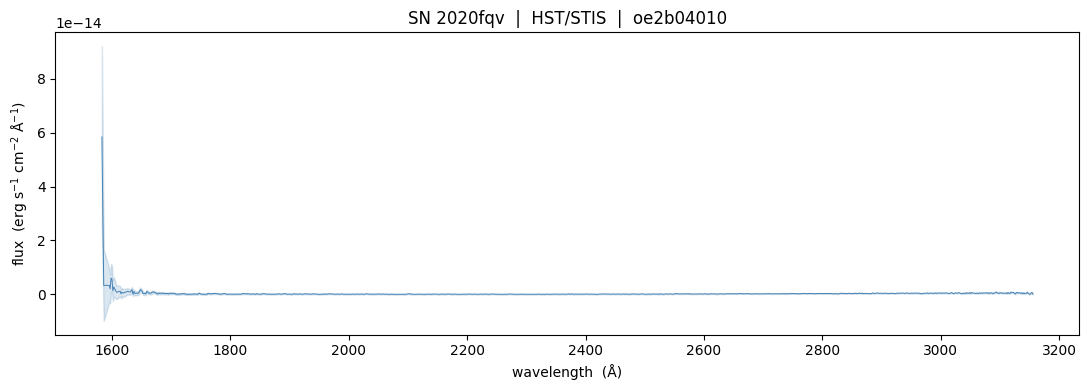

In [ ]:
# pull products from the filtered sci_obs table, grab x1d files
products = Observations.get_product_list(sci_obs)
x1d = Observations.filter_products(products, productSubGroupDescription="X1D", extension="fits")
print(f"{len(x1d)} x1d files available — downloading first one")

manifest = Observations.download_products(x1d[:1], download_dir="./data")
fpath = manifest["Local Path"][0]

with fits.open(fpath) as hdul:
    spec   = hdul[1].data
    wvl    = spec["WAVELENGTH"][0]
    flux   = spec["FLUX"][0]
    err    = spec["ERROR"][0]
    hdr    = hdul[0].header
    obs_id = hdr.get("ROOTNAME", "unknown")

# drop bad pixels, negatives and NaNs from pipeline
mask = np.isfinite(flux) & np.isfinite(err) & (flux > 0) & (err > 0)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(wvl[mask], flux[mask], lw=0.7, color="steelblue")
ax.fill_between(wvl[mask], flux[mask] - err[mask], flux[mask] + err[mask],
                alpha=0.2, color="steelblue")
ax.set_xlabel("wavelength  (Å)")
ax.set_ylabel("flux  (erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)")
ax.set_title(f"SN 2020fqv  |  HST/STIS  |  {obs_id}")
plt.tight_layout()
plt.show()


---
## SN2024iss STIS test

Shoulda done this bfor: SN2024iss, pull the 2D + default x1d, then run our own ocrreject + x1d trace instead of trusting the pipeline.


In [2]:
# MAST logs SNe under whatever name the proposer typed, so query_criteria(target_name=...) misses.
# objectname runs the name resolver (simbad/ned) -> coords, then cone searches. no manual coords needed.
for nm in ["SN2024iss", "SN 2024iss", "AT2024iss", "2024iss"]:
    try:
        t = Observations.query_criteria(objectname=nm, obs_collection="HST",
                                         instrument_name="STIS*", radius="0.05 deg")
        print(f"{nm:12s} -> {len(t)} STIS obs")
        if len(t):
            iss = t
            break
    except Exception as e:
        print(f"{nm:12s} -> resolver failed ({e})")

iss["obs_id", "instrument_name", "filters", "t_exptime", "target_name", "proposal_id"]


SN2024iss    -> 8 STIS obs


obs_id,instrument_name,filters,t_exptime,target_name,proposal_id
str34,str8,str18,float64,str10,str5
of8b02010,STIS/CCD,G230LB,1923.0,SN2024ISS,17507
hst_hasp_17507_stis_sn2024iss_of8b,STIS,G230LB;G430L;G750L,5905.0,SN2024ISS,17507
of8b02hfq,STIS/CCD,MIRVIS,4.1,SN2024ISS,17507
of8b02030,STIS/CCD,G430L,1065.0,SN2024ISS,17507
of8b02haq,STIS/CCD,MIRVIS,4.1,SN2024ISS,17507
hst_hsla_sn2024iss--6540,STIS,G230LB;G430L;G750L,5905.0,SN 2024iss,17507
of8b02020,STIS/CCD,G230LB,1857.0,SN2024ISS,17507
of8b02040,STIS/CCD,G750L,1060.0,SN2024ISS,17507


In [ ]:
# grab the G230LB exposure (of8b02010, same one the reference uses).
# CCD CRSPLIT data so the pipeline 1d product is SX1 (from the CR-rejected CRJ), not X1D like the mama data.
# flt = flat-fielded 2d subexposures for our own ocrreject. crj/sx1 = pipeline default to compare against.
sci = iss[iss["obs_id"] == "of8b02010"]
prod = Observations.get_product_list(sci)
want = Observations.filter_products(prod, productSubGroupDescription=["FLT", "CRJ", "SX1"], extension="fits")
man = Observations.download_products(want, download_dir="./Data/2024iss")
man["Local Path", "Status"]


INFO: Found cached file ./Data/2024iss\mastDownload\HST\of8b02010\of8b02010_flt.fits with expected size 31567680. [astroquery.query]


Local Path,Status
str60,str8
./Data/2024iss\mastDownload\HST\of8b02010\of8b02010_crj.fits,COMPLETE
./Data/2024iss\mastDownload\HST\of8b02010\of8b02010_flt.fits,COMPLETE
./Data/2024iss\mastDownload\HST\of8b02010\of8b02010_sx1.fits,COMPLETE


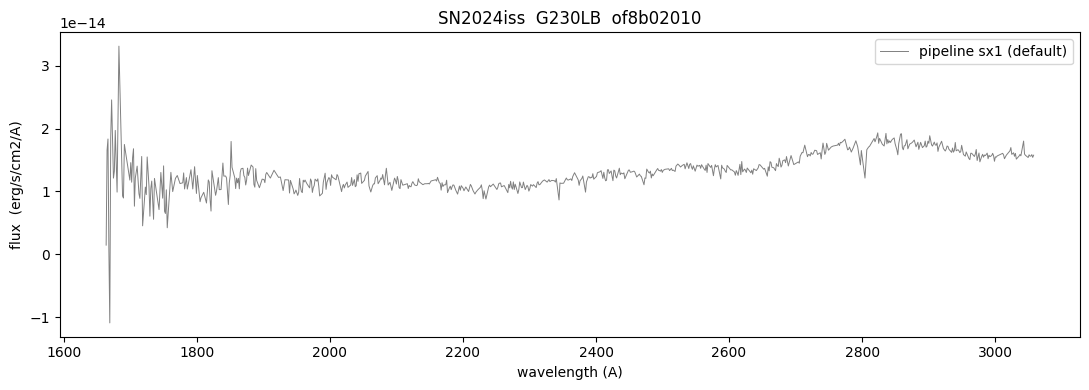

In [ ]:
from astropy.table import Table

obsdir   = "./Data/2024iss/mastDownload/HST/of8b02010"
flt      = f"{obsdir}/of8b02010_flt.fits"
crj_pipe = f"{obsdir}/of8b02010_crj.fits"
sx1_pipe = f"{obsdir}/of8b02010_sx1.fits"

# pipeline default 1d extraction (sx1) (what MAST hands us)
sx1 = Table.read(sx1_pipe, hdu=1)
wvl, flx, err, dq = sx1['WAVELENGTH'][0], sx1['FLUX'][0], sx1['ERROR'][0], sx1['DQ'][0]
good = (dq & 16 != 16) & (dq & 512 != 512)

plt.figure(figsize=(11, 4))
plt.plot(wvl[good], flx[good], lw=0.7, color='0.5', label='pipeline sx1 (default)')
plt.xlabel('wavelength (A)'); plt.ylabel('flux  (erg/s/cm2/A)')
plt.title('SN2024iss  G230LB  of8b02010'); plt.legend()
plt.tight_layout(); plt.show()


In [ ]:
import os, glob

# stis reduction tools need the crds reference files, resolved through the oref env var.
os.environ['CRDS_SERVER_URL'] = 'https://hst-crds.stsci.edu' # calibration data files
os.environ['CRDS_PATH'] = os.path.abspath('./crds_cache')

# crds on a fresh windows cache errors out writing files before it makes these dirs, so make them first
for sub in ('mappings/hst', 'references/hst', 'config/hst'):
    os.makedirs(f"{os.environ['CRDS_PATH']}/{sub}", exist_ok=True)

import crds # NOTE: SETTING UP CRDS empirically
# downloads the bestref files for these into the cache and stamps the headers with oref$...
crds.assign_bestrefs([flt, crj_pipe], sync_references=True)

# find where crds stashed the stis refs and point oref there so stistools can resolve oref$...
hits = [f for f in glob.glob(os.environ['CRDS_PATH'] + '/references/hst/**', recursive=True) if f.endswith('.fits')]
oref_dir = os.path.dirname(hits[0]) + os.sep
os.environ['oref'] = oref_dir
print(len(hits), "ref files in", oref_dir)


21 ref files in c:\Users\eluru\CALTECH_SURF_2026\WORK\crds_cache/references/hst\stis\


In [10]:
import shutil, stistools.ocrreject, stistools.x1d

crj_ours = f"{obsdir}/230_crj_ours.fits"
x1d_ours = f"{obsdir}/230_x1d_ours.fits"

# stistools is just a wrapper around the compiled hstcal binaries (cs2.e=ocrreject, cs6.e=x1d).
# those dont exist on native windows (hstcal is conda/linux only), so check before calling.
have_hstcal = shutil.which("cs2.e") is not None
print("hstcal available:", have_hstcal)

if have_hstcal:
    for f in (crj_ours, x1d_ours):
        if os.path.exists(f):
            os.remove(f)
    stistools.ocrreject.ocrreject(flt, crj_ours, verbose=False)   # our own CR reject -> our crj
    stistools.x1d.x1d(crj_ours, output=x1d_ours, verbose=False)   # our own 1d extraction
    print("done")
else:
    print("skipping our ocrreject/x1d - needs hstcal binaries (see data_access.md). using pipeline crj/sx1 for the viz below.")


hstcal available: False
skipping our ocrreject/x1d - needs hstcal binaries (see data_access.md). using pipeline crj/sx1 for the viz below.


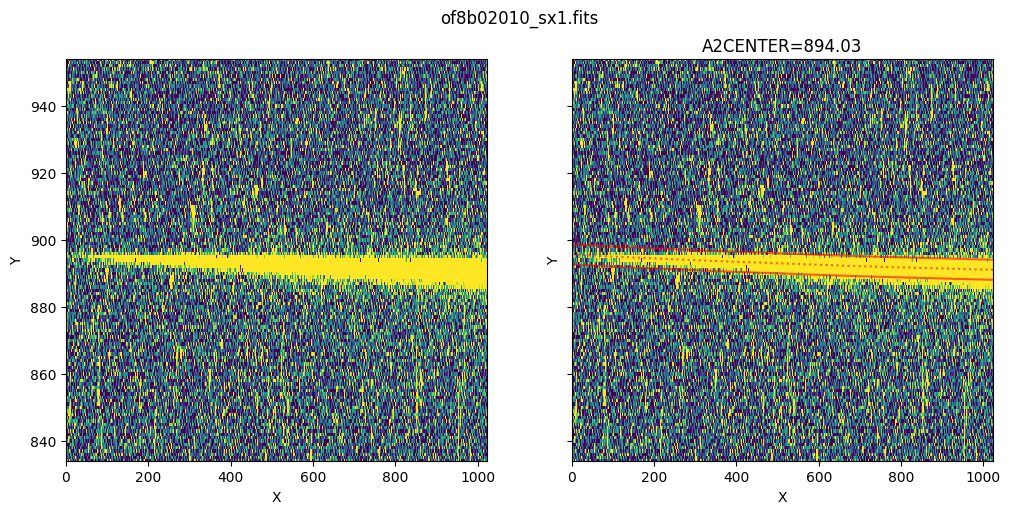

In [ ]:
# 2d trace + extraction regions (same helper as the reference notebook).
# red = extraction aperture down the trace, orange = the two bg regions.
def show_extraction_regions(x1d_filename, flt_filename, sci_ext=1, row=0, xrange=None, yrange=None):
    fig, axes = plt.subplots(1, 2, sharey=True, figsize=(10, 5))
    fig.tight_layout(); fig.subplots_adjust(wspace=0.2, top=0.88)
    fig.suptitle(os.path.basename(x1d_filename))

    x1d = fits.getdata(x1d_filename, ext=sci_ext)[row]
    flt = fits.getdata(flt_filename, ext=('SCI', sci_ext))

    for ax in axes:
        ax.imshow(flt, origin='lower', interpolation='none', aspect='auto', vmin=-6, vmax=15)
        ax.set_xlabel('X'); ax.set_ylabel('Y')

    axes[1].set_title(f"A2CENTER={x1d['A2CENTER']:.2f}")
    # extraction region (red)
    axes[1].plot(np.arange(1024), x1d['EXTRLOCY'] - 1, 'r:', alpha=0.6)
    axes[1].plot(np.arange(1024), x1d['EXTRLOCY'] - 1 - x1d['EXTRSIZE'] // 2, color='red', alpha=0.6)
    axes[1].plot(np.arange(1024), x1d['EXTRLOCY'] - 1 + x1d['EXTRSIZE'] // 2, color='red', alpha=0.6)
    # bg regions (orange)
    axes[1].plot(np.arange(1024), x1d['EXTRLOCY'] - 1 + x1d['BK1OFFST'] - x1d['BK1SIZE'] // 2, color='orange', alpha=0.6)
    axes[1].plot(np.arange(1024), x1d['EXTRLOCY'] - 1 + x1d['BK1OFFST'] + x1d['BK1SIZE'] // 2, color='orange', alpha=0.6) # adjust this
    axes[1].plot(np.arange(1024), x1d['EXTRLOCY'] - 1 + x1d['BK2OFFST'] - x1d['BK2SIZE'] // 2, color='orange', alpha=0.6) # adjust this
    axes[1].plot(np.arange(1024), x1d['EXTRLOCY'] - 1 + x1d['BK2OFFST'] + x1d['BK2SIZE'] // 2, color='orange', alpha=0.6)

    for ax in axes:
        ax.set_xlim(-0.5, 1023.5); ax.set_ylim(-0.5, 1023.5)
    if xrange: axes[0].set_xlim(*xrange); axes[1].set_xlim(*xrange)
    if yrange: axes[0].set_ylim(*yrange); axes[1].set_ylim(*yrange)
    # constrain y to 870-910 and review aperture

from astropy.io import fits
a2 = fits.getdata(sx1_pipe, ext=1)[0]['A2CENTER']
show_extraction_regions(sx1_pipe, flt, yrange=[a2 - 60, a2 + 60])
plt.show()


### our own extraction (ran in WSL)

turns out hstcal binaries dont run on native windows, so the actual ocrreject + x1d ran in WSL (Debian, `surf_uv` conda env) via `reduce_stis.py`. it reused the crds refs we synced above and wrote `230_crj_ours.fits` / `230_x1d_ours.fits` back into the same folder. now read our x1d back and compare to the pipeline sx1.


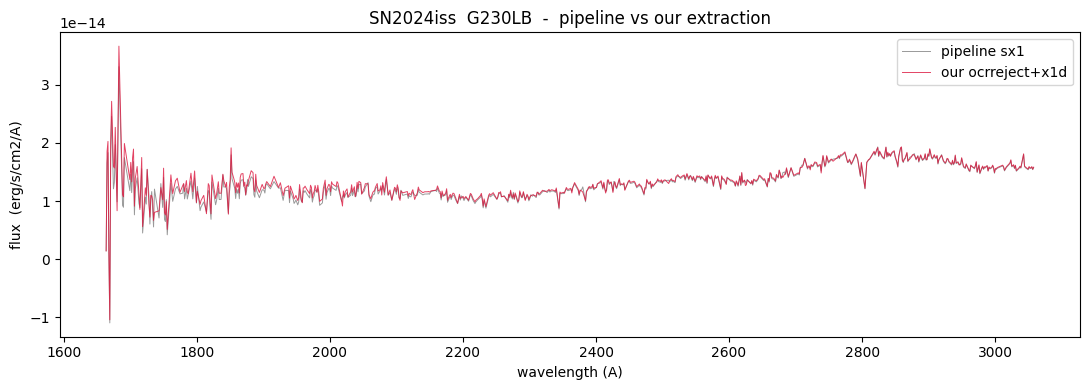

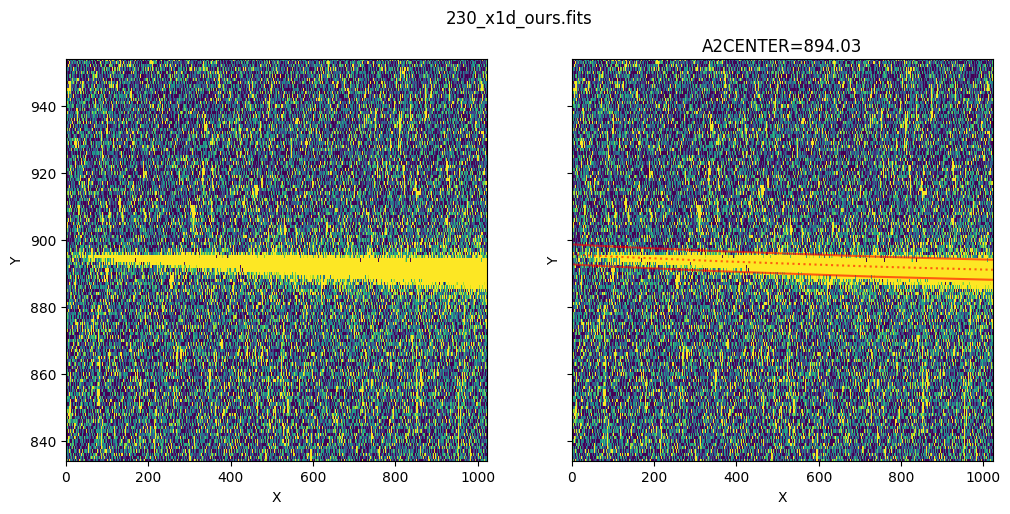

In [12]:
# read our wsl-made x1d and overplot on the pipeline sx1
ours = Table.read(x1d_ours, hdu=1)
w_o, f_o, dq_o = ours['WAVELENGTH'][0], ours['FLUX'][0], ours['DQ'][0]
g_o = (dq_o & 16 != 16) & (dq_o & 512 != 512)

plt.figure(figsize=(11, 4))
plt.plot(wvl[good], flx[good], lw=0.7, color='0.6', label='pipeline sx1')
plt.plot(w_o[g_o], f_o[g_o], lw=0.7, color='crimson', alpha=0.8, label='our ocrreject+x1d')
plt.xlabel('wavelength (A)'); plt.ylabel('flux  (erg/s/cm2/A)')
plt.title('SN2024iss  G230LB  -  pipeline vs our extraction'); plt.legend()
plt.tight_layout(); plt.show()

# our extraction regions on the 2d
a2o = ours[0]['A2CENTER']
show_extraction_regions(x1d_ours, flt, yrange=[a2o - 60, a2o + 60])
plt.show()


---
## COS test

STIS done. Now COS. First lets just find a SN that actually has some COS UV data and pull MAST's default x1d to look at it. COS is photon-counting (calcos), so apparently custom extraction later is a different beast than stistools.x1d (edit XTRACTAB boxes + rerun calcos).


In [13]:
# find SNe with COS spectra. target_name is proposer-typed but a lot of SNe do get logged as 'SN*'
cos = Observations.query_criteria(obs_collection="HST", instrument_name="COS*", target_name="SN*")
print(f"{len(cos)} COS obs under SN* names")

# collapse to unique targets so we can pick one
from astropy.table import unique
u = unique(cos, keys="target_name")
u["target_name", "filters", "t_exptime", "proposal_id"]


148 COS obs under SN* names


target_name,filters,t_exptime,proposal_id
str19,str41,float64,str5
SN 1895B,G130M;G160M,8166.656000000001,MULTI
SN 1968L,G130M;G160M,3084.2239999999997,MULTI
SN 1983I,E140M;G130M;G160M;G750M,20644.528,MULTI
SN 1987A,G130M;G160M;G230L;G430L;G430M;G750L;G750M,54153.52799999999,MULTI
SN 1993J,G140L;G230L,29968.127999999997,12531
SN 2009ip,G130M;G140L;G160M;G230LB;G430L;G750L,10719.864,MULTI
SN 2010al,G140L;G230LB;G430L,8400.0,11654
SN 2010jl,G130M;G140L;G160M;G230L;G430L,20549.688,MULTI
SN 2014C,G140L;G230LB;G430L,10617.648000000001,14202


In [ ]:
# go with SN2023ixf - type II in M101. dedicated COS G230L visit (prop 17497)
ixf = Observations.query_criteria(objectname="SN2023ixf", obs_collection="HST", instrument_name="COS*", radius="0.01 deg") # before it was 3 arcmin, made smaller to 0.01-0.02 deg ~ 0.6 arcmin
print(f"{len(ixf)} COS obs near SN2023ixf")
ixf["obs_id", "instrument_name", "filters", "t_exptime", "target_name", "proposal_id"]


10 COS obs near SN2023ixf


obs_id,instrument_name,filters,t_exptime,target_name,proposal_id
str37,str8,str23,float64,str13,str5
ldjia3010,COS/FUV,G140L,1972.0,+254.6-107.2,15126
lf8803050,COS/NUV,G230L,1700.192,SN2023IXF-COS,17497
hst_hsla_sn2023ixf--3586,COS-STIS,G140L;G230L;G430L;G750L,12697.126625,SN 2023ixf,MULTI
lf8803d3q,COS/NUV,MIRRORA,5.0,SN2023IXF-COS,17497
lf8803030,COS/NUV,G230L,1700.192,SN2023IXF-COS,17497
lf8803040,COS/NUV,G230L,629.184,SN2023IXF-COS,17497
lf8803010,COS/NUV,G230L,1700.192,SN2023IXF-COS,17497
lf8803020,COS/NUV,G230L,337.0,SN2023IXF-COS,17497
hst_hasp_17497_cos_sn2023ixf-cos_lf88,COS,G230L,6704.928,SN2023IXF-COS,17497


In [15]:
# grab one COS/NUV G230L exposure and pull its default x1dsum (the summed 1d product)
one = ixf[ixf["obs_id"] == "lf8803010"]
cprod = Observations.get_product_list(one)
cx1d = Observations.filter_products(cprod, productSubGroupDescription=["X1DSUM", "X1D"], extension="fits")
cman = Observations.download_products(cx1d, download_dir="./Data/2023ixf")
cman["Local Path", "Status"]


Local Path,Status
str63,str8
./Data/2023ixf\mastDownload\HST\lf8803010\lf8803010_x1dsum.fits,COMPLETE
./Data/2023ixf\mastDownload\HST\lf8803d5q\lf8803d5q_x1d.fits,COMPLETE


3 stripes: ['NUVA', 'NUVB', 'NUVC']


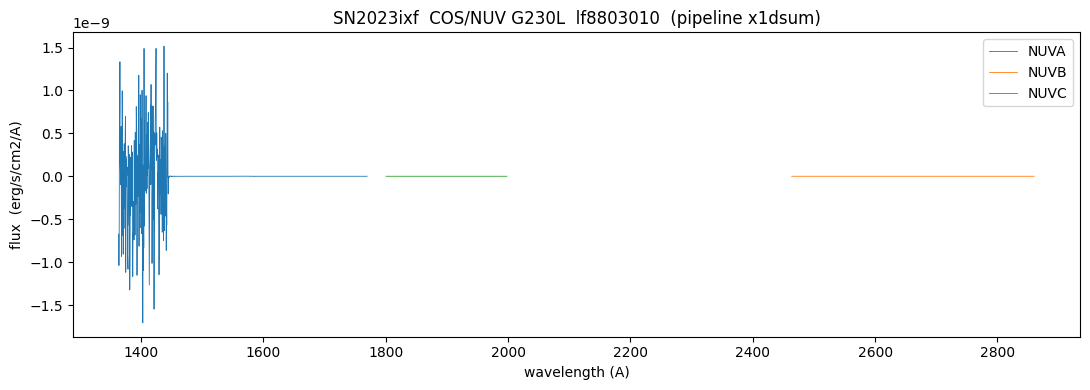

In [16]:
# COS NUV lands on 3 stripes (NUVA/B/C) so the x1dsum has 3 rows. COS masks on DQ_WGT (0 = thrown out)
cosx1d = "./Data/2023ixf/mastDownload/HST/lf8803010/lf8803010_x1dsum.fits"
ct = Table.read(cosx1d, hdu=1)
print(len(ct), "stripes:", list(ct['SEGMENT']))

plt.figure(figsize=(11, 4))
for r in ct:
    w, f, dqw = r['WAVELENGTH'], r['FLUX'], r['DQ_WGT']
    m = dqw > 0
    plt.plot(w[m], f[m], lw=0.6, label=r['SEGMENT'])
plt.xlabel('wavelength (A)'); plt.ylabel('flux  (erg/s/cm2/A)')
plt.title('SN2023ixf  COS/NUV G230L  lf8803010  (pipeline x1dsum)'); plt.legend()
plt.tight_layout(); plt.show()


INFO: Found cached file ./Data/2023ixf\mastDownload\HST\lf8803050\lf8803050_asn.fits with expected size 11520. [astroquery.query]
INFO: Found cached file ./Data/2023ixf\mastDownload\HST\lf8803050\lf8803050_jif.fits with expected size 34560. [astroquery.query]
INFO: Found cached file ./Data/2023ixf\mastDownload\HST\lf8803050\lf8803050_jit.fits with expected size 77760. [astroquery.query]
INFO: Found cached file ./Data/2023ixf\mastDownload\HST\lf8803050\lf8803050_trl.fits with expected size 8640. [astroquery.query]
INFO: Found cached file ./Data/2023ixf\mastDownload\HST\lf8803050\lf8803050_x1dsum3.fits with expected size 259200. [astroquery.query]
INFO: Found cached file ./Data/2023ixf\mastDownload\HST\lf8803050\lf8803050_x1dsum_prev.fits with expected size 115200. [astroquery.query]
INFO: Found cached file ./Data/2023ixf\mastDownload\HST\lf8803050\lf8803050_x1dsum3_prev.fits with expected size 115200. [astroquery.query]
INFO: Found cached file ./Data/2023ixf\mastDownload\HST\lf8803050\l

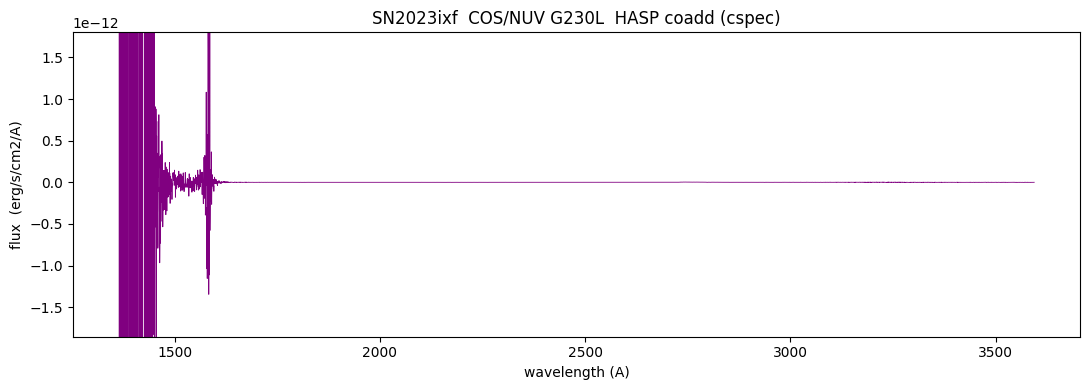

In [ ]:
# i guess one exposure is faint. lets try grabbing the HASP coadd of the whole G230L visit for a clean look (details in data_access)
hasp = ixf[ixf["obs_id"] == "hst_hasp_17497_cos_sn2023ixf-cos_lf88"]
hprod = Observations.get_product_list(hasp)
hman = Observations.download_products(hprod, download_dir="./Data/2023ixf", extension="fits")
cspec_path = [p for p in hman["Local Path"] if p.endswith("cspec.fits")][0]

hc = Table.read(cspec_path, hdu=1)
w, f, eff = hc['WAVELENGTH'][0], hc['FLUX'][0], hc['EFF_EXPTIME'][0]
# only where there's real coadded coverage. the blue edge has huge-error spikes that wreck the y-scale, so clip those
m = (eff > 0) & np.isfinite(f)
lo, hi = np.nanpercentile(f[m], [2, 98])

plt.figure(figsize=(11, 4))
plt.plot(w[m], f[m], lw=0.6, color='purple')
plt.ylim(lo - abs(lo), hi * 1.3)
plt.xlabel('wavelength (A)'); plt.ylabel('flux  (erg/s/cm2/A)')
plt.title('SN2023ixf  COS/NUV G230L  HASP coadd (cspec)')
plt.tight_layout(); plt.show() # uh oh that pulled the full product set (all the rawtag/corrtag/flt too, not just cspec)
# NOTE: ^ can use these as calcos inputs later


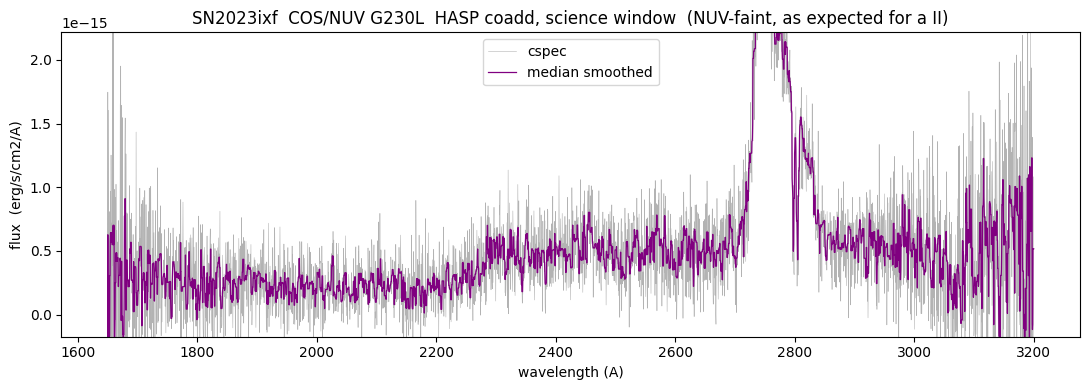

In [20]:
# zoom into the actual G230L science window (the blue end <1650 is 2nd-order/airglow junk).
# uses the in-memory cspec from the cell above so no re-download.
from scipy.ndimage import median_filter
sci = m & (w > 1650) & (w < 3200)
wsci = np.asarray(w[sci], dtype=float)
fsci = np.asarray(f[sci], dtype=float)   # fits is big-endian, scipy wants native
fs = median_filter(fsci, size=7)         # light smooth just to see the continuum shape
lo, hi = np.nanpercentile(fsci, [5, 95])

plt.figure(figsize=(11, 4))
plt.plot(wsci, fsci, lw=0.4, color='0.7', label='cspec')
plt.plot(wsci, fs, lw=0.9, color='purple', label='median smoothed')
plt.ylim(lo - abs(lo), hi * 1.4)
plt.xlabel('wavelength (A)'); plt.ylabel('flux  (erg/s/cm2/A)')
plt.title('SN2023ixf  COS/NUV G230L  HASP coadd, science window  (NUV-faint, as expected for a II)')
plt.legend(); plt.tight_layout(); plt.show()
